# 🛒 E-Commerce Intelligence Platform
## Phase 3 — SQL Analysis
**Goal:** Answer real business questions using SQL queries  
**Database:** SQLite (loaded from cleaned master data)  
**Analyst:** Shivansh Pandey

In [1]:
# ============================================================
# CELL 1 — IMPORTS & UPLOAD CLEAN FILES
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
import warnings

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

# Upload clean files
from google.colab import files
uploaded = files.upload()

print("✅ Libraries imported & files uploaded")

Saving master_dataset.csv to master_dataset.csv
Saving orders_clean.csv to orders_clean.csv
Saving products_clean.csv to products_clean.csv
Saving reviews_clean.csv to reviews_clean.csv
✅ Libraries imported & files uploaded


In [2]:
# ============================================================
# CELL 2 — CREATE SQLITE DATABASE
# Load all clean dataframes into a SQL database
# ============================================================

# Load cleaned CSVs
master   = pd.read_csv('master_dataset.csv')
orders   = pd.read_csv('orders_clean.csv')
products = pd.read_csv('products_clean.csv')
reviews  = pd.read_csv('reviews_clean.csv')

# Create SQLite database in memory
conn = sqlite3.connect('ecommerce.db')

# Load dataframes as SQL tables
master.to_sql('master', conn, if_exists='replace', index=False)
orders.to_sql('orders', conn, if_exists='replace', index=False)
products.to_sql('products', conn, if_exists='replace', index=False)
reviews.to_sql('reviews', conn, if_exists='replace', index=False)

print("✅ SQLite database created!")
print("\n📋 Tables available:")
tables = pd.read_sql("SELECT name FROM sqlite_master WHERE type='table'", conn)
print(tables)

✅ SQLite database created!

📋 Tables available:
       name
0    master
1    orders
2  products
3   reviews


In [3]:
# ============================================================
# CELL 3 — SQL HELPER FUNCTION
# Makes running & displaying SQL queries clean and easy
# ============================================================

def run_sql(query, title=""):
    """Run a SQL query and return results as a styled dataframe"""
    df = pd.read_sql(query, conn)
    if title:
        print(f"\n{'='*55}")
        print(f"  📊 {title}")
        print(f"{'='*55}")
    print(df.to_string(index=False))
    return df

print("✅ Helper function ready")

✅ Helper function ready



  📊 Monthly Revenue Trend
  month  total_orders  total_revenue  avg_order_value
2017-01           750      176491.49           193.31
2017-02          1653      325782.66           175.34
2017-03          2546      505735.83           174.57
2017-04          2303      456108.32           177.54
2017-05          3545      701119.60           175.15
2017-06          3135      585400.98           167.78
2017-07          3872      716069.98           162.15
2017-08          4193      842689.94           175.67
2017-09          4150      996279.59           210.32
2017-10          4478      998609.62           191.52
2017-11          7288     1548547.86           182.74
2017-12          5513     1020067.26           164.87
2018-01          7069     1374064.02           170.97
2018-02          6555     1279970.45           170.25
2018-03          7003     1435458.33           179.05
2018-04          6798     1466607.15           187.38
2018-05          6749     1480667.59           189.59
2

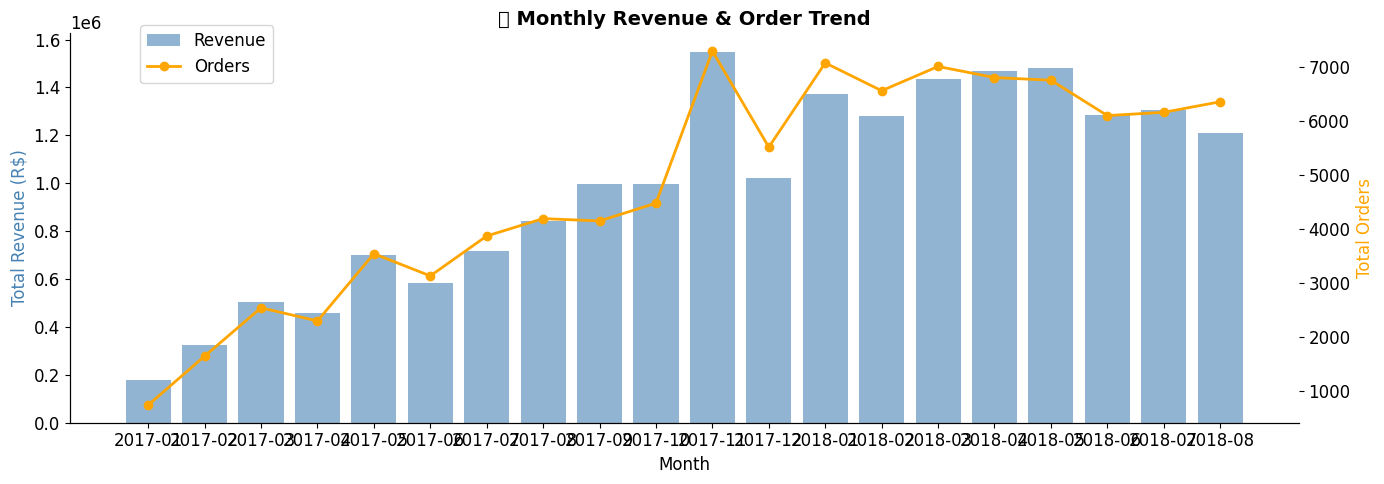

In [4]:
# ============================================================
# QUERY 1 — MONTHLY REVENUE TREND
# Business Question: Is revenue growing month over month?
# ============================================================

q1 = run_sql("""
    SELECT
        SUBSTR(order_purchase_timestamp, 1, 7)  AS month,
        COUNT(DISTINCT order_id)                AS total_orders,
        ROUND(SUM(total_payment), 2)            AS total_revenue,
        ROUND(AVG(total_payment), 2)            AS avg_order_value
    FROM master
    WHERE order_purchase_timestamp >= '2017-01-01'
      AND order_purchase_timestamp <  '2018-09-01'
    GROUP BY month
    ORDER BY month
""", "Monthly Revenue Trend")

# Visualize
fig, ax1 = plt.subplots(figsize=(14, 5))
ax2 = ax1.twinx()

ax1.bar(q1['month'], q1['total_revenue'], color='steelblue', alpha=0.6, label='Revenue')
ax2.plot(q1['month'], q1['total_orders'], color='orange', marker='o', linewidth=2, label='Orders')

ax1.set_xlabel('Month')
ax1.set_ylabel('Total Revenue (R$)', color='steelblue')
ax2.set_ylabel('Total Orders', color='orange')
plt.xticks(rotation=45, ha='right')
plt.title('📈 Monthly Revenue & Order Trend', fontsize=14, fontweight='bold')
fig.legend(loc='upper left', bbox_to_anchor=(0.1, 0.95))
plt.tight_layout()
plt.show()


  📊 Top 10 Product Categories by Revenue
             category  total_orders  total_revenue  avg_review_score
       bed_bath_table          9272     1692714.28              3.92
        health_beauty          8647     1620684.04              4.19
computers_accessories          6529     1549252.47              3.99
      furniture_decor          6307     1394466.93              3.95
        watches_gifts          5493     1387046.31              4.07
       sports_leisure          7529     1349252.93              4.17
           housewares          5743     1069787.97              4.11
                 auto          3809      833610.84              4.11
         garden_tools          3448      810614.93              4.08
           cool_stuff          3559      744649.32              4.20


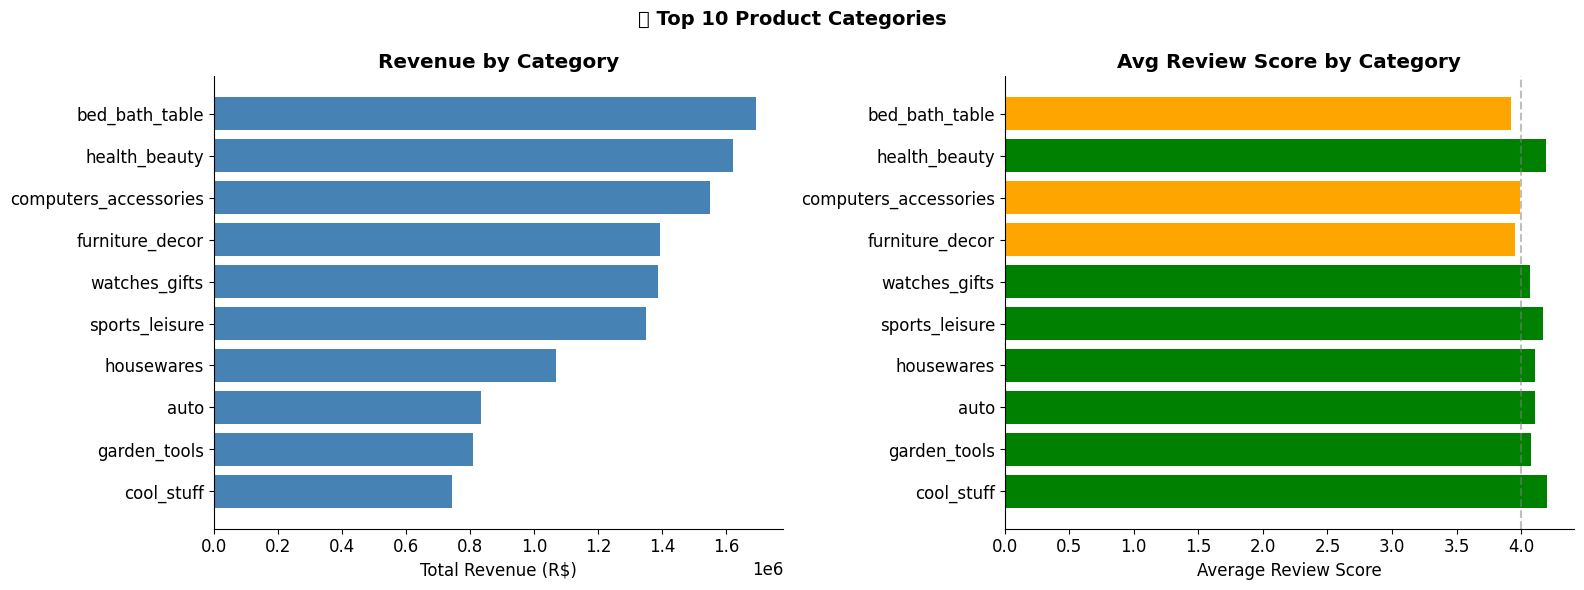

In [5]:
# ============================================================
# QUERY 2 — TOP 10 PRODUCT CATEGORIES BY REVENUE
# Business Question: What categories drive the most revenue?
# ============================================================

q2 = run_sql("""
    SELECT
        product_category_name_english           AS category,
        COUNT(DISTINCT order_id)                AS total_orders,
        ROUND(SUM(total_payment), 2)            AS total_revenue,
        ROUND(AVG(review_score), 2)             AS avg_review_score
    FROM master
    WHERE product_category_name_english != 'unknown'
    GROUP BY category
    ORDER BY total_revenue DESC
    LIMIT 10
""", "Top 10 Product Categories by Revenue")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Revenue chart
axes[0].barh(q2['category'], q2['total_revenue'], color='steelblue')
axes[0].set_title('Revenue by Category', fontweight='bold')
axes[0].set_xlabel('Total Revenue (R$)')
axes[0].invert_yaxis()

# Review score chart
colors = ['green' if x >= 4 else 'orange' if x >= 3 else 'red' for x in q2['avg_review_score']]
axes[1].barh(q2['category'], q2['avg_review_score'], color=colors)
axes[1].set_title('Avg Review Score by Category', fontweight='bold')
axes[1].set_xlabel('Average Review Score')
axes[1].axvline(x=4, color='gray', linestyle='--', alpha=0.5)
axes[1].invert_yaxis()

plt.suptitle('🏆 Top 10 Product Categories', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


  📊 Late Delivery Rate by State (Top 15 Worst)
state  total_orders  late_orders  late_rate_pct  avg_delivery_days
   AL           427          103          24.10              24.00
   MA           800          163          20.40              21.20
   SE           375           61          16.30              21.00
   PI           523           81          15.50              18.90
   CE          1426          218          15.30              20.50
   BA          3683          504          13.70              18.80
   RJ         14143         1835          13.00              14.70
   PA          1054          131          12.40              23.30
   TO           310           38          12.30              17.00
   ES          2225          272          12.20              15.20
   PB           586           66          11.30              20.10
   MS           811           88          10.90              15.10
   RN           521           54          10.40              18.90
   PE         

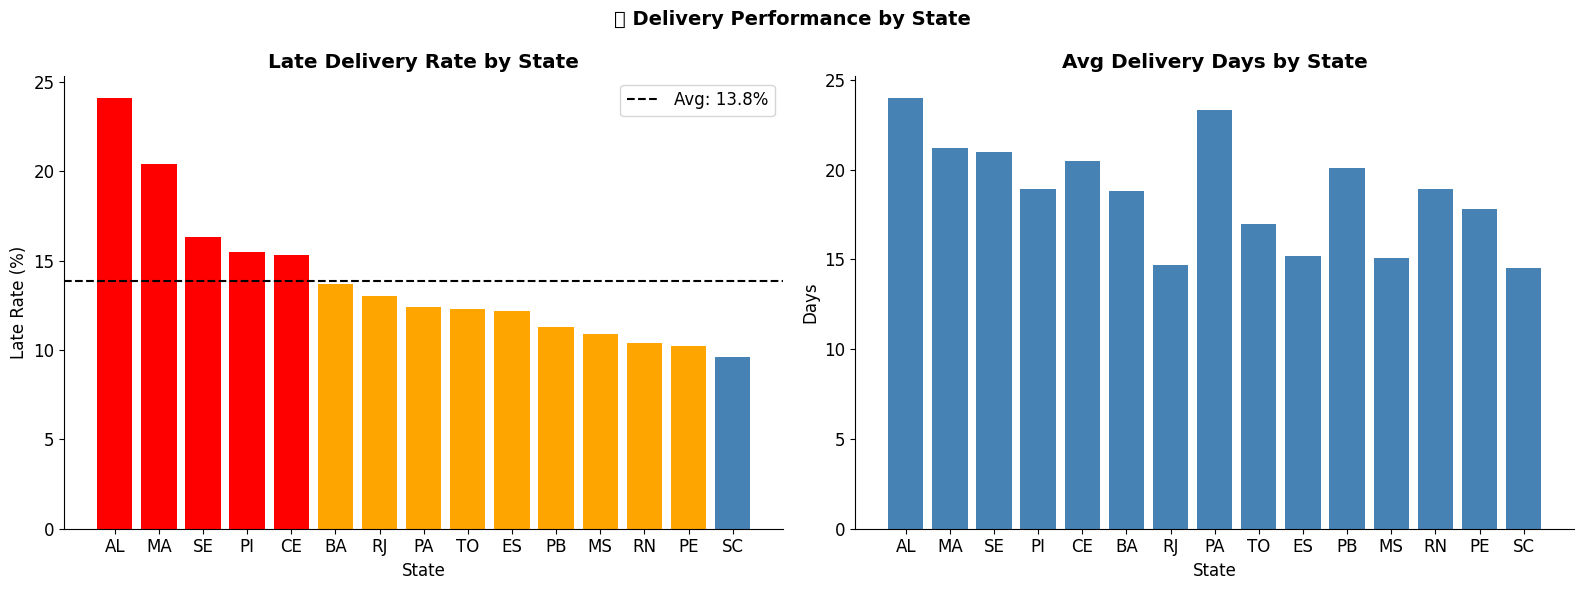

In [6]:
# ============================================================
# QUERY 3 — LATE DELIVERY RATE BY STATE
# Business Question: Where are operations failing?
# ============================================================

q3 = run_sql("""
    SELECT
        customer_state                              AS state,
        COUNT(*)                                    AS total_orders,
        SUM(is_late)                                AS late_orders,
        ROUND(SUM(is_late) * 100.0 / COUNT(*), 1)  AS late_rate_pct,
        ROUND(AVG(delivery_days), 1)                AS avg_delivery_days
    FROM master
    GROUP BY state
    HAVING total_orders > 100
    ORDER BY late_rate_pct DESC
    LIMIT 15
""", "Late Delivery Rate by State (Top 15 Worst)")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

colors = ['red' if x > 15 else 'orange' if x > 10 else 'steelblue' for x in q3['late_rate_pct']]

axes[0].bar(q3['state'], q3['late_rate_pct'], color=colors)
axes[0].set_title('Late Delivery Rate by State', fontweight='bold')
axes[0].set_xlabel('State')
axes[0].set_ylabel('Late Rate (%)')
axes[0].axhline(y=q3['late_rate_pct'].mean(), color='black',
                linestyle='--', label=f"Avg: {q3['late_rate_pct'].mean():.1f}%")
axes[0].legend()

axes[1].bar(q3['state'], q3['avg_delivery_days'], color='steelblue')
axes[1].set_title('Avg Delivery Days by State', fontweight='bold')
axes[1].set_xlabel('State')
axes[1].set_ylabel('Days')

plt.suptitle('🚚 Delivery Performance by State', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


  📊 Review Score Impact on Revenue
 review_score  total_orders  total_revenue  avg_order_value  avg_delivery_days
         1.00          9351     3062624.65           245.32              19.10
         2.00          2921      721644.72           196.69              15.30
         3.00          7916     1611778.20           175.29              13.60
         4.00         18888     3599595.81           170.88              11.70
         5.00         56748    10567469.49           167.88              10.20


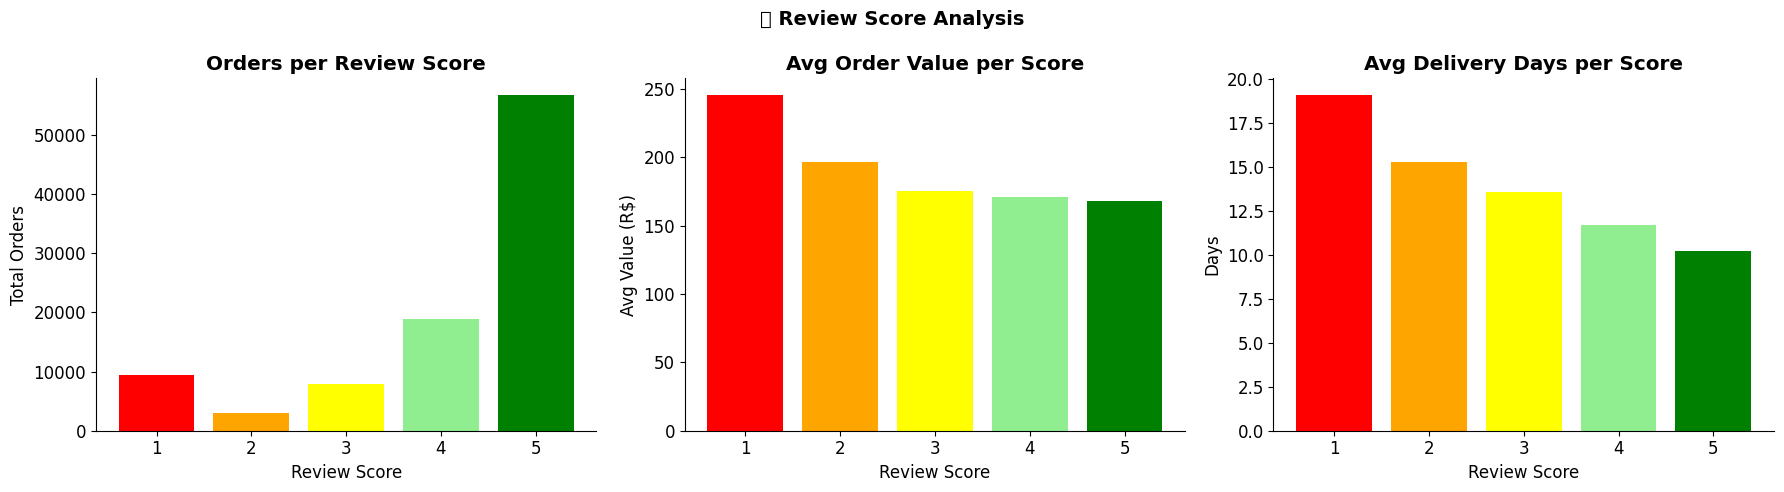

In [7]:
# ============================================================
# QUERY 4 — REVIEW SCORE IMPACT ON REVENUE
# Business Question: Does customer satisfaction affect sales?
# ============================================================

q4 = run_sql("""
    SELECT
        review_score,
        COUNT(DISTINCT order_id)        AS total_orders,
        ROUND(SUM(total_payment), 2)    AS total_revenue,
        ROUND(AVG(total_payment), 2)    AS avg_order_value,
        ROUND(AVG(delivery_days), 1)    AS avg_delivery_days
    FROM master
    WHERE review_score IS NOT NULL
    GROUP BY review_score
    ORDER BY review_score
""", "Review Score Impact on Revenue")

# Visualize
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

colors = ['red', 'orange', 'yellow', 'lightgreen', 'green']

axes[0].bar(q4['review_score'], q4['total_orders'], color=colors)
axes[0].set_title('Orders per Review Score', fontweight='bold')
axes[0].set_xlabel('Review Score')
axes[0].set_ylabel('Total Orders')

axes[1].bar(q4['review_score'], q4['avg_order_value'], color=colors)
axes[1].set_title('Avg Order Value per Score', fontweight='bold')
axes[1].set_xlabel('Review Score')
axes[1].set_ylabel('Avg Value (R$)')

axes[2].bar(q4['review_score'], q4['avg_delivery_days'], color=colors)
axes[2].set_title('Avg Delivery Days per Score', fontweight='bold')
axes[2].set_xlabel('Review Score')
axes[2].set_ylabel('Days')

plt.suptitle('⭐ Review Score Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


  📊 Customer Repeat Purchase Rate
 order_count  num_customers
           1          90549
           2           2573
           3            181
           4             28
           5              9
           6              5
           7              3
           9              1
          15              1


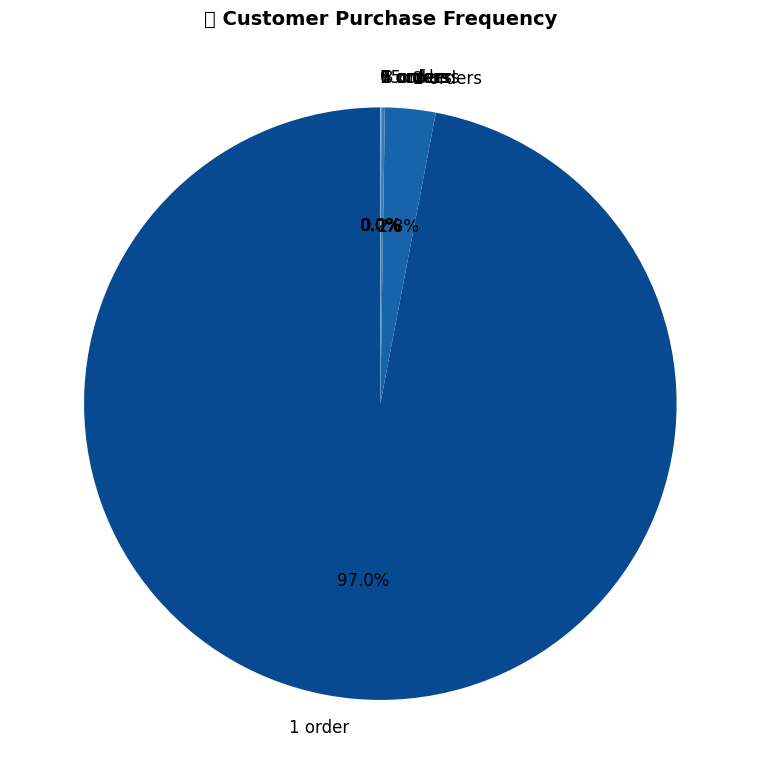


📊 Repeat Customer Rate: 3.0%
   One-time customers  : 90,549
   Repeat customers    : 2,801


In [8]:
# ============================================================
# QUERY 5 — CUSTOMER REPEAT PURCHASE RATE
# Business Question: How loyal are our customers?
# ============================================================

q5 = run_sql("""
    SELECT
        order_count,
        COUNT(*) AS num_customers
    FROM (
        SELECT
            customer_unique_id,
            COUNT(DISTINCT o.order_id) AS order_count
        FROM master m
        JOIN orders o ON m.order_id = o.order_id
        GROUP BY customer_unique_id
    )
    GROUP BY order_count
    ORDER BY order_count
""", "Customer Repeat Purchase Rate")

# Visualize
labels = [f"{int(row['order_count'])} order{'s' if row['order_count']>1 else ''}"
          for _, row in q5.iterrows()]

plt.figure(figsize=(8, 8))
plt.pie(q5['num_customers'], labels=labels, autopct='%1.1f%%',
        colors=sns.color_palette('Blues_r', len(q5)), startangle=90)
plt.title('🔄 Customer Purchase Frequency', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

repeat = q5[q5['order_count'] > 1]['num_customers'].sum()
total  = q5['num_customers'].sum()
print(f"\n📊 Repeat Customer Rate: {repeat/total*100:.1f}%")
print(f"   One-time customers  : {q5[q5['order_count']==1]['num_customers'].values[0]:,}")
print(f"   Repeat customers    : {repeat:,}")


  📊 Top 10 Sellers by Revenue
                       seller_id seller_state  total_orders  total_revenue  avg_review_score  avg_delivery_days
7c67e1448b00f6e969d365cea6b010ab           SP           973      505437.16              3.35              21.90
1025f0e2d44d7041d6cf58b6550e0bfa           SP           910      306000.35              3.86              11.60
4a3ca9315b744ce9f8e9374361493884           SP          1772      295830.76              3.83              13.90
1f50f920176fa81dab994f9023523100           SP          1399      289861.38              3.99              15.10
53243585a1d6dc2643021fd1853d8905           BA           348      279843.42              4.13              12.90
da8622b14eb17ae2831f4ac5b9dab84a           SP          1311      271733.78              4.07              10.70
4869f7a5dfa277a7dca6462dcf3b52b2           SP          1124      261532.48              4.14              14.50
955fee9216a65b617aa5c0531780ce60           SP          1261      232136.0

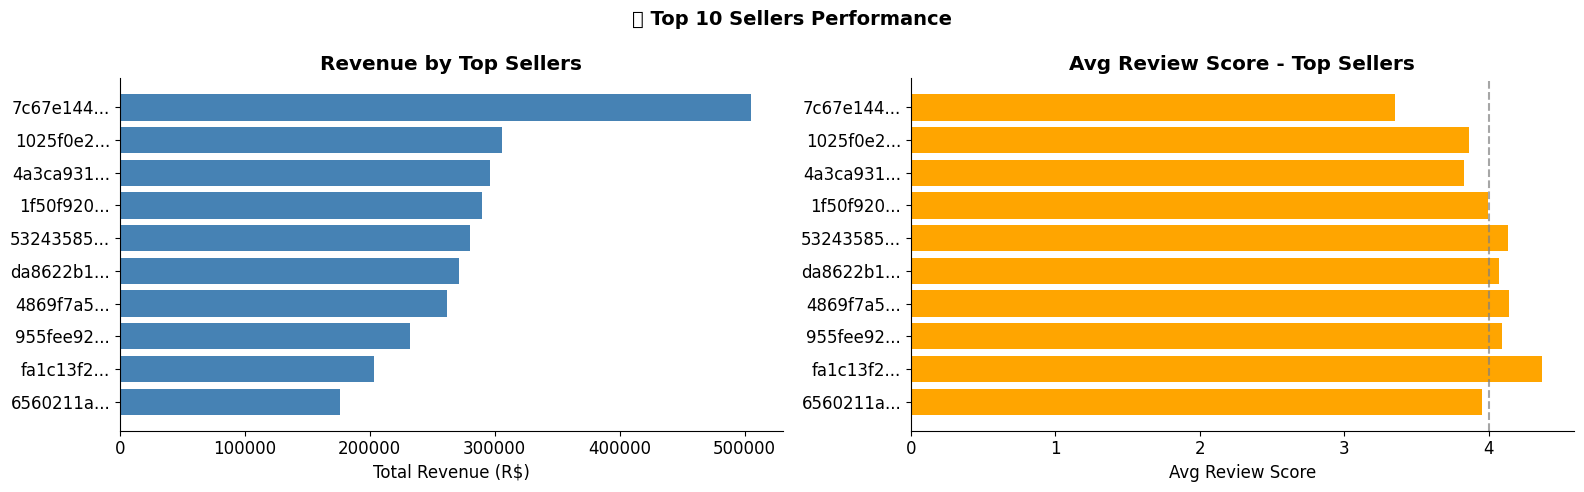

In [9]:
# ============================================================
# QUERY 6 — TOP 10 SELLERS BY REVENUE
# Business Question: Who are our best performing sellers?
# ============================================================

q6 = run_sql("""
    SELECT
        seller_id,
        seller_state,
        COUNT(DISTINCT order_id)        AS total_orders,
        ROUND(SUM(total_payment), 2)    AS total_revenue,
        ROUND(AVG(review_score), 2)     AS avg_review_score,
        ROUND(AVG(delivery_days), 1)    AS avg_delivery_days
    FROM master
    GROUP BY seller_id
    ORDER BY total_revenue DESC
    LIMIT 10
""", "Top 10 Sellers by Revenue")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Shorten seller_id for display
q6['seller_short'] = q6['seller_id'].str[:8] + '...'

axes[0].barh(q6['seller_short'], q6['total_revenue'], color='steelblue')
axes[0].set_title('Revenue by Top Sellers', fontweight='bold')
axes[0].set_xlabel('Total Revenue (R$)')
axes[0].invert_yaxis()

axes[1].barh(q6['seller_short'], q6['avg_review_score'], color='orange')
axes[1].set_title('Avg Review Score - Top Sellers', fontweight='bold')
axes[1].set_xlabel('Avg Review Score')
axes[1].axvline(x=4, color='gray', linestyle='--', alpha=0.7)
axes[1].invert_yaxis()

plt.suptitle('🏅 Top 10 Sellers Performance', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [10]:
# ============================================================
# QUERY 7 — OVERALL BUSINESS HEALTH SUMMARY
# ============================================================

summary = run_sql("""
    SELECT
        COUNT(DISTINCT order_id)                        AS total_orders,
        COUNT(DISTINCT customer_unique_id)              AS total_customers,
        COUNT(DISTINCT seller_id)                       AS total_sellers,
        ROUND(SUM(total_payment), 2)                    AS total_revenue,
        ROUND(AVG(total_payment), 2)                    AS avg_order_value,
        ROUND(AVG(review_score), 2)                     AS avg_review_score,
        ROUND(SUM(is_late) * 100.0 / COUNT(*), 1)       AS late_delivery_pct,
        ROUND(AVG(delivery_days), 1)                    AS avg_delivery_days
    FROM master
""", "📋 Overall Business Health Summary")

print("\n✅ Phase 3 Complete — SQL Analysis Done!")


  📊 📋 Overall Business Health Summary
 total_orders  total_customers  total_sellers  total_revenue  avg_order_value  avg_review_score  late_delivery_pct  avg_delivery_days
        96470            93350           2970    19774781.52           179.47              4.08               7.90              12.00

✅ Phase 3 Complete — SQL Analysis Done!
